# 📊 Estatística espectral — Welch e autocorrelação
por: **Iury Coelho**

Nos notebooks anteriores usamos a **FFT direta** (o *periodograma*) para achar
frequências. Ela funciona, mas tem um defeito: é **ruidosa** — o espectro fica
"peludo" e não melhora por mais longo que seja o sinal. Para *ler* o conteúdo de
um sinal real (cheio de ruído) de forma confiável, há ferramentas melhores:

- **Welch** — divide o sinal em janelas, calcula o espectro de cada e tira a
  **média**, produzindo uma estimativa **estável** da densidade espectral de
  potência (PSD).
- **Autocorrelação** — detecta **periodicidade** direto no tempo: um sinal que se
  repete a cada $T$ segundos tem um pico de autocorrelação em $T$.

São os pilares da estimação robusta — e explicam por que nossos detectores de
respiração/batimento aguentaram tanto ruído.

#### Conteúdo
* [1. O periodograma é ruidoso](#1)
* [2. Welch: média de janelas](#2)
* [3. Mais janelas, mais suave](#3)
* [4. Autocorrelação: periodicidade no tempo](#4)
* [5. Sensing robusto: três caminhos](#5)
* [6. Da simulação ao mundo real](#6)
* [7. Exercício](#7)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as ss

plt.rcParams["figure.figsize"] = (9, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

def autocorrelacao(x):
    # autocorrelacao normalizada (via FFT), lado nao-negativo
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)
    P = np.abs(np.fft.rfft(x, 2*n))**2
    acf = np.fft.irfft(P)[:n]
    return acf / acf[0]

<a id="1"></a>
## 1. O periodograma é ruidoso

Geramos um sinal com **respiração (0,30 Hz)** e **batimento (1,20 Hz, fraco)** sob
**ruído forte**. O periodograma (FFT direta ao quadrado) mostra os picos, mas
afogados num "capim" de variância — difícil de ler com confiança.

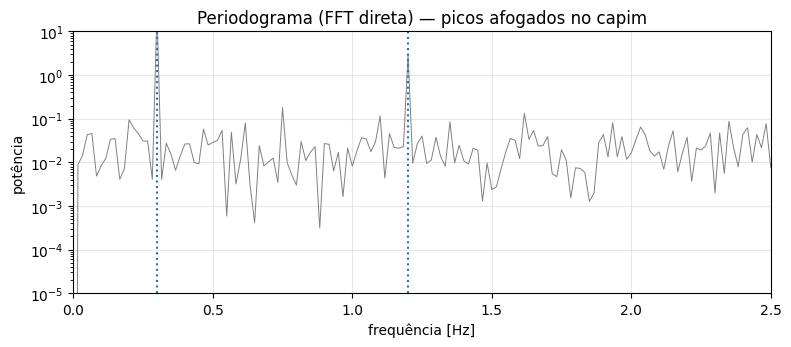

In [2]:
fs = 50.0
dur = 60.0
t = np.arange(0, dur, 1/fs)
rng = np.random.default_rng(0)

resp = 1.0*np.sin(2*np.pi*0.30*t)        # 18/min
card = 0.3*np.sin(2*np.pi*1.20*t)        # 72 bpm, fraco
ruido = 0.8*rng.standard_normal(len(t))  # forte
x = resp + card + ruido

f_p, P_p = ss.periodogram(x, fs)
plt.semilogy(f_p, P_p, "0.5", lw=0.7)
plt.xlim(0, 2.5); plt.ylim(1e-5, 1e1)
for fc in (0.30, 1.20):
    plt.axvline(fc, color="C0", ls=":")
plt.title("Periodograma (FFT direta) — picos afogados no capim")
plt.xlabel("frequência [Hz]"); plt.ylabel("potência"); plt.show()

<a id="2"></a>
## 2. Welch: a média que estabiliza

O método de **Welch** corta o sinal em janelas sobrepostas, calcula o espectro de
cada uma e **promedia**. A variância despenca: os mesmos picos de respiração e
batimento agora saltam aos olhos, limpos.

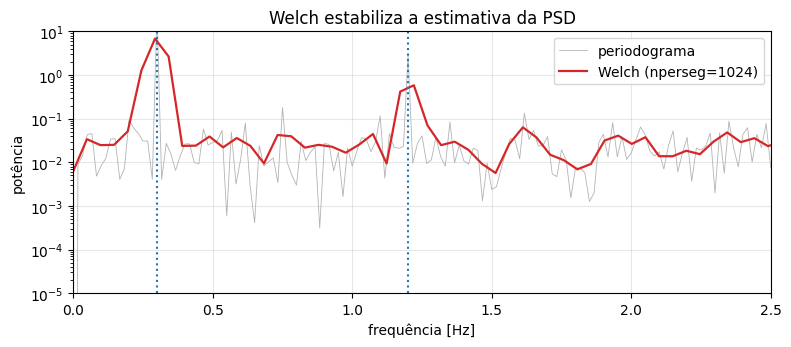

In [3]:
f_w, P_w = ss.welch(x, fs, nperseg=1024)

plt.semilogy(f_p, P_p, "0.7", lw=0.6, label="periodograma")
plt.semilogy(f_w, P_w, "C3", lw=1.6, label="Welch (nperseg=1024)")
plt.xlim(0, 2.5); plt.ylim(1e-5, 1e1)
for fc in (0.30, 1.20):
    plt.axvline(fc, color="C0", ls=":")
plt.title("Welch estabiliza a estimativa da PSD")
plt.xlabel("frequência [Hz]"); plt.ylabel("potência"); plt.legend(); plt.show()

<a id="3"></a>
## 3. Mais janelas, mais suave (e menos resolução)

Há um compromisso: janelas **menores** cabem em maior número → média sobre mais
pedaços → espectro **mais suave**, porém com **menos resolução** em frequência
(picos mais largos). Janelas **maiores** → melhor resolução, menos média (mais
ruidoso). É o mesmo trade-off do espectrograma (nb09), agora na estimativa de
potência.

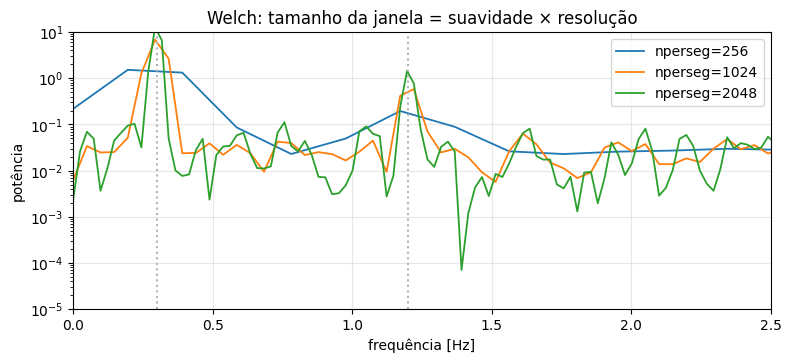

In [4]:
plt.figure(figsize=(9, 3.6))
for nperseg, cor in [(256, "C0"), (1024, "C1"), (2048, "C2")]:
    fW, PW = ss.welch(x, fs, nperseg=nperseg)
    plt.semilogy(fW, PW, cor, lw=1.3, label=f"nperseg={nperseg}")
plt.xlim(0, 2.5); plt.ylim(1e-5, 1e1)
for fc in (0.30, 1.20):
    plt.axvline(fc, color="0.7", ls=":")
plt.title("Welch: tamanho da janela = suavidade × resolução")
plt.xlabel("frequência [Hz]"); plt.ylabel("potência"); plt.legend(); plt.show()

<a id="4"></a>
## 4. Autocorrelação: a periodicidade no tempo

Outra rota, sem olhar o espectro: a **autocorrelação** mede o quanto o sinal se
parece com versões deslocadas de si mesmo. Um sinal periódico de período $T$ tem
um **pico** de autocorrelação no atraso (*lag*) $T$. Para a nossa respiração
(0,30 Hz), o período é $1/0{,}30 \approx 3{,}3$ s — e é lá que o pico aparece.

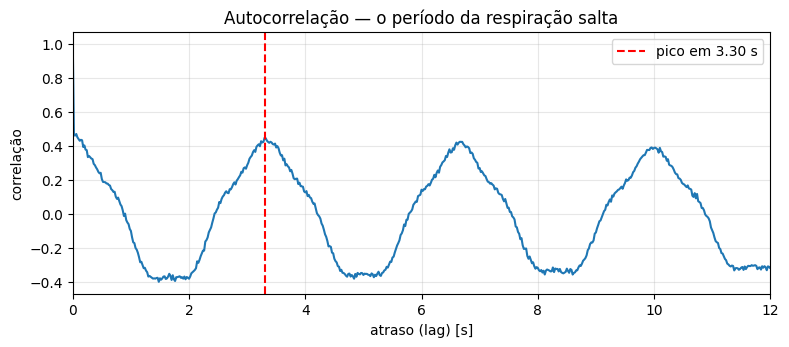

Respiração pela autocorrelação: período 3.30 s -> 18.2 por minuto


In [5]:
acf = autocorrelacao(x)
lags = np.arange(len(acf)) / fs

# primeiro pico na faixa de respiracao (periodo entre 1.5 s e 8 s)
faixa = (lags >= 1.5) & (lags <= 8.0)
T = lags[faixa][np.argmax(acf[faixa])]
rpm = 60 / T

plt.plot(lags, acf, "C0")
plt.axvline(T, color="r", ls="--", label=f"pico em {T:.2f} s")
plt.xlim(0, 12)
plt.title("Autocorrelação — o período da respiração salta")
plt.xlabel("atraso (lag) [s]"); plt.ylabel("correlação"); plt.legend(); plt.show()
print(f"Respiração pela autocorrelação: período {T:.2f} s -> {rpm:.1f} por minuto")

<a id="5"></a>
## 5. Sensing robusto: três caminhos para o mesmo número

Vamos estimar a respiração de três formas — FFT direta, Welch e autocorrelação —
e comparar. Todas miram a faixa 0,1–0,6 Hz.

In [6]:
def por_fft(x):
    X = np.abs(np.fft.rfft(x)); f = np.fft.rfftfreq(len(x), 1/fs)
    m = (f >= 0.1) & (f <= 0.6); return f[m][np.argmax(X[m])]*60

def por_welch(x):
    f, P = ss.welch(x, fs, nperseg=1024)
    m = (f >= 0.1) & (f <= 0.6); return f[m][np.argmax(P[m])]*60

def por_autocorr(x):
    acf = autocorrelacao(x); lags = np.arange(len(acf))/fs
    m = (lags >= 1.5) & (lags <= 8.0); return 60/lags[m][np.argmax(acf[m])]

print("respiração real = 18/min\n")
print(f"FFT direta:      {por_fft(x):5.1f}/min")
print(f"Welch:           {por_welch(x):5.1f}/min")
print(f"Autocorrelação:  {por_autocorr(x):5.1f}/min")

respiração real = 18/min

FFT direta:       18.0/min
Welch:            17.6/min
Autocorrelação:   18.2/min


<a id="6"></a>
## 6. Da simulação ao mundo real

Sistemas de sensoriamento (como o RuView) raramente confiam num único
periodograma. Eles usam **Welch/PSD** para enxergar o espectro de forma estável,
**autocorrelação** para travar a periodicidade do batimento/respiração, e
combinam as duas com janelas deslizantes para acompanhar mudanças no tempo.

> ⚠️ Didático. Sinais reais têm ruído colorido, artefatos de movimento e
> múltiplas periodicidades que exigem mais cuidado.

Você agora tem o ferramental para extrair frequência **de forma robusta** — não
só "rodar uma FFT". 🚀

<a id="7"></a>
## 7. Exercício

__Exercício__ — Aumente o ruído de `0.8` para `3.0` e rode as três estimativas de
novo. Qual delas se mantém mais estável? E reduza a duração `dur` de 60 s para
15 s (menos dados): o que acontece com a resolução do Welch e com a nitidez do
pico de autocorrelação?

In [7]:
def gerar(ruido, dur, seed=1):
    tt = np.arange(0, dur, 1/fs)
    rng = np.random.default_rng(seed)
    return tt, (1.0*np.sin(2*np.pi*0.30*tt) + 0.3*np.sin(2*np.pi*1.20*tt)
                + ruido*rng.standard_normal(len(tt)))

print("respiração real = 18/min  (faixa de busca 0.1-0.6 Hz)\n")
for ru, du in [(0.8, 60), (3.0, 60), (3.0, 15)]:
    tt, xx = gerar(ru, du)
    fX = np.abs(np.fft.rfft(xx)); ff = np.fft.rfftfreq(len(xx), 1/fs)
    mf = (ff >= 0.1) & (ff <= 0.6); e_fft = ff[mf][np.argmax(fX[mf])]*60
    nps = min(1024, len(xx))
    fw, Pw = ss.welch(xx, fs, nperseg=nps); mw = (fw >= 0.1) & (fw <= 0.6)
    e_w = fw[mw][np.argmax(Pw[mw])]*60
    ac = autocorrelacao(xx); lg = np.arange(len(ac))/fs; ma = (lg >= 1.5) & (lg <= 8.0)
    e_a = 60/lg[ma][np.argmax(ac[ma])]
    print(f"ruído={ru}, dur={du:>2}s  ->  FFT={e_fft:5.1f}  Welch={e_w:5.1f}  Autocorr={e_a:5.1f}")

respiração real = 18/min  (faixa de busca 0.1-0.6 Hz)

ruído=0.8, dur=60s  ->  FFT= 18.0  Welch= 17.6  Autocorr= 18.2
ruído=3.0, dur=60s  ->  FFT= 18.0  Welch= 17.6  Autocorr=  9.0
ruído=3.0, dur=15s  ->  FFT= 16.0  Welch= 16.0  Autocorr= 17.2


__Resposta__: não há um vencedor universal — cada estimador **falha de um jeito
diferente**, e os números mostram isso. A **FFT direta** resiste muito bem ao
ruído (soma coerente, ganho de processamento), mas com poucos dados (15 s) sua
resolução cai e ela confunde 18 com ~16/min. O **Welch** troca resolução por
estabilidade — fica sempre um pouco abaixo (~17,6). A **autocorrelação** é precisa
no período, porém com ruído muito alto pode **travar num pico espúrio** (note o
~9/min). É por isso que sistemas reais não confiam num só estimador: combinam-nos
e usam janelas no tempo para se proteger das falhas de cada um.

---
<br>[⬆ volte ao topo](#Conteúdo)